**Spinny's** Revenue Growth Through Demand and Pricing Optimisation

STEP 1 : Download the dataset and import all the libraries that will be used.


In [1]:
# Step 1: Install gdown
!pip install gdown

# Step 2: Import necessary libraries
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Set the file ID and create a download URL
file_id = "1QQaRZizuq3TGhUqHyIc701ChT-GgM1yR"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Step 4: Set the output file name
output_file = "spinny_dataset.csv"

# Step 5: Download the file
gdown.download(download_url, output_file, quiet=False)

# Step 6: Load the CSV file into a Pandas DataFrame
data = pd.read_csv(output_file)

Downloading...
From: https://drive.google.com/uc?id=1QQaRZizuq3TGhUqHyIc701ChT-GgM1yR
To: /content/spinny_dataset.csv
100%|██████████| 99.9M/99.9M [00:00<00:00, 118MB/s]


STEP 2 : Data Cleaning and Preparation

1. Data Exploration

1.1. Checking the data types in the dataset

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   price         426880 non-null  float64
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  VIN           265838 non-null  object 
 12  drive         296313 non-null  object 
 13  size          120519 non-null  object 
 14  type          334022 non-null  object 
 15  paint_color   296677 non-null  object 
 16  image_url     426812 non-null  object 
 17  state         426880 non-null  object 
 18  post

1.2. Checking for missing values in the dataset

In [3]:
data.isnull().sum()

,0
id,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678
fuel,3013
odometer,4400
title_status,8242


1.3. Checking for duplicate values in the dataset.

In [4]:
data.duplicated().sum()

0

2.Handling Missing Values.

2.1. imputing missing values in the numerical columns with mean values.       
     List of numerical columns of the missing values are :    
     1.year     
     2.odometer

In [5]:
data['year'] = data['year'].fillna(data['year'].median())

data['odometer'] = data['odometer'].fillna(data['odometer'].median())

2.2. imputing missing values in the Categorical columns with mode values.       
List of Categorical columns of the missing values are :   
manufacturer, model, condition, fuel,     
title_status ,transmission,drive,type,cylinders

In [6]:
categorical_columns = ['manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'drive', 'type','cylinders']
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

2.3. Drop columns with more than 50% missing values     
The columns are :    
1.size    
2.paint_color    
3.VTN

In [7]:
data = data.drop(columns=['size', 'paint_color', 'VIN'])

2.4. Drop the rows with the missing values for posting_date and image_url

In [8]:
data = data.dropna(subset=['posting_date', 'image_url'])

Verifying the data after handling the missing values

In [9]:
data.isnull().sum()

,0
id,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0


3. Converting the datatype if needed

3.1. convert year datatype from float to int.  
     convert posting_date from object to datetime

In [10]:
data['year'] = data['year'].astype(int)

data['posting_date'] = pd.to_datetime(data['posting_date'], errors='coerce')
data.dtypes

,0
id,int64
price,float64
year,int64
manufacturer,object
model,object
condition,object
cylinders,object
fuel,object
odometer,float64
title_status,object


4. Check for Outliers. (here i used IQR method)

In [11]:
# Detect outliers in 'Price' using the IQR method
Q1 = data['price'].quantile(0.25)  # First quartile (25th percentile)
Q3 = data['price'].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  # Interquartile range

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Print the bounds
print(f"Price Lower Bound: {lower_bound}")
print(f"Price Upper Bound: {upper_bound}")

# Filter the data to remove outliers
data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]


Price Lower Bound: -3209055.0
Price Upper Bound: 7368905.0


There are no extreme otliers.  

5. Feature Engineering  

create derived columns for Car_Age from year and Region from state column.   
create normalized columns for Price and Odometer.

In [12]:
data = data.copy()
data['Car_Age'] = 2023 - data['year']

In [13]:
region_map = {
    'Delhi': 'North', 'Haryana': 'North', 'Karnataka': 'South', 'Maharashtra': 'West',
    'Punjab': 'North', 'Rajasthan': 'South', 'Tamil Nadu': 'South', 'Telangana': 'South',
    'West Bengal': 'East','Andhra Pradesh' : 'South','Gujarat' : 'West','Himachal Pradesh' : 'North','Jammu and Kashmir' : 'North',
    'Jharkhand' : 'East','Kerala' : 'South','Madhya Pradesh' : 'South','Odisha' : 'East','Uttar Pradesh' : 'North','Uttarakhand' : 'North',
    'Puducherry' : 'South','Chandigarh' : 'North','Goa' : 'South','Assam' : 'East','Bihar' : 'East','Chhattisgarh' : 'East',
    'Dadra and Nagar Haveli' : 'South','Daman and Diu' : 'South', 'Lakshadweep' : 'South', 'Manipur' : 'East', 'Meghalaya' : 'East',
    'Mizoram' : 'East', 'Nagaland' : 'East', 'Sikkim' : 'East', 'Tripura' : 'East' , 'Arunachal Pradesh' : 'East' ,
    'Andaman and Nicobar Islands' : 'South' , 'Ladakh' : 'North'
}
data['Region'] = data['state'].map(region_map)

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Use .loc to assign normalized values to new columns
data.loc[:, ['Price_normalized', 'Odometer_normalized']] = scaler.fit_transform(data[['price', 'odometer']])

5.1. Checking for datatypes for the added columns.

In [15]:
data.dtypes

,0
id,int64
price,float64
year,int64
manufacturer,object
model,object
condition,object
cylinders,object
fuel,object
odometer,float64
title_status,object


5.2. Checking for missing values and duplicate values for the added columns.

In [16]:
data.isnull().sum()

,0
id,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0


AS Region column has missing values it is filled with mode values of the columns.

In [17]:
categorical_columns = ['Region']
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

In [18]:
data.isnull().sum()

,0
id,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0


In [19]:
data.duplicated().sum()

0

6. Save the dataset after cleaning the dataset for the further use.

In [20]:
data.to_csv('spinny_dataset.csv', index=False)

STEP 3 :    EDA(Exploratory Data Analysis)   
Hypothesis 1: Demand by Region.

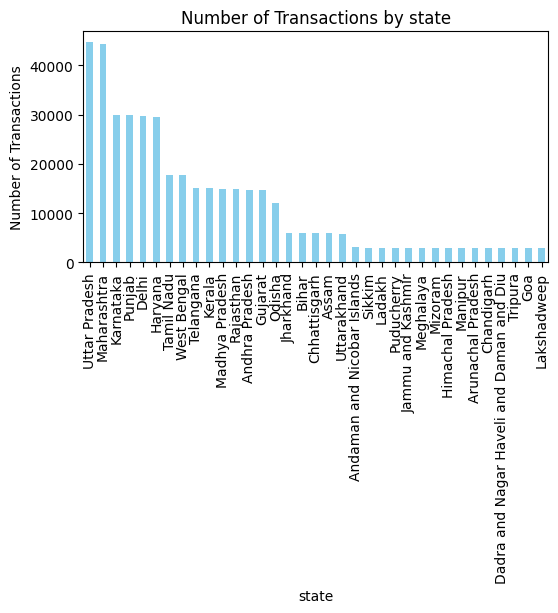

In [21]:
#group by state
state_demand = data.groupby('state')['id'].count().sort_values(ascending=False)
#Bar Graph is used
plt.figure(figsize=(6, 3))
state_demand.plot(kind='bar', color='skyblue')
plt.title("Number of Transactions by state")
plt.xlabel("state")
plt.ylabel("Number of Transactions")
plt.show()

Hypothesis 2 : Demand by Car Type.

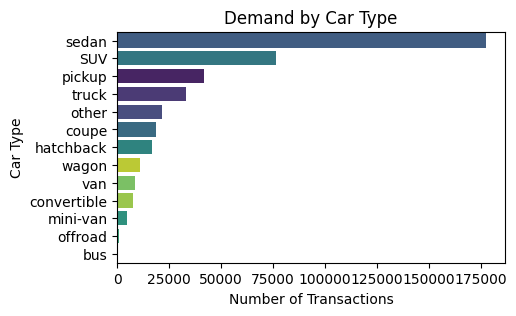

In [22]:
#countplot is used
plt.figure(figsize=(5, 3))
sns.countplot(data=data, y='type',order=data['type'].value_counts().index,palette='viridis',hue='type')
plt.title("Demand by Car Type")
plt.xlabel("Number of Transactions")
plt.ylabel("Car Type")
plt.show()

Hypothesis 3: Demand by Fuel Type.

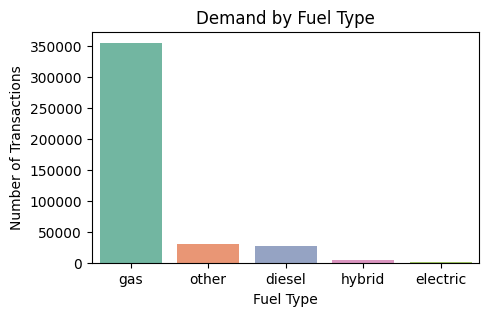

In [23]:
#countplot is used
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x='fuel', order=data['fuel'].value_counts().index, palette='Set2',hue='fuel')
plt.title("Demand by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Transactions")
plt.show()

Hypothesis 4 : Price vs Car Age (How the price changes according to the age of the car the more the care age the less of price).

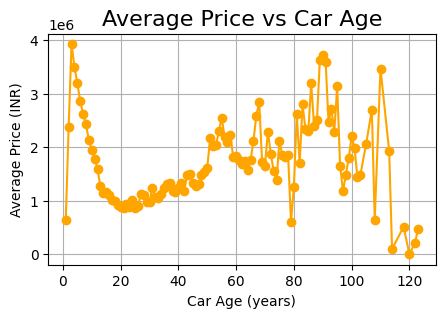

In [24]:
#group by Car_Age
car_age_price = data.groupby('Car_Age')['price'].mean()
#Line Graph is used
plt.figure(figsize=(5, 3))
car_age_price.plot(kind='line', marker='o', color='orange')
plt.title("Average Price vs Car Age", fontsize=16)
plt.xlabel("Car Age (years)")
plt.ylabel("Average Price (INR)")
plt.grid(True)
plt.show()


Hypothesis 5 : Price vs Odometer (The lower the Odometer reading higher of price).

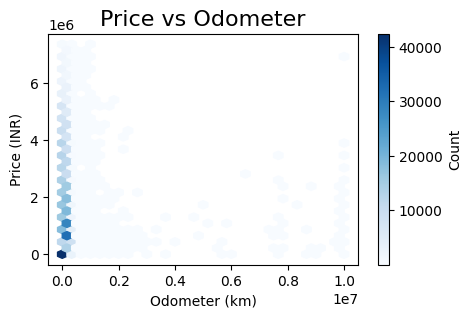

In [25]:
#Hexbin Plot is used
plt.figure(figsize=(5, 3))
plt.hexbin(data['odometer'], data['price'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(label='Count')
plt.title("Price vs Odometer", fontsize=16)
plt.xlabel("Odometer (km)")
plt.ylabel("Price (INR)")
plt.show()


Hypothesis 6 : Price by Condition.

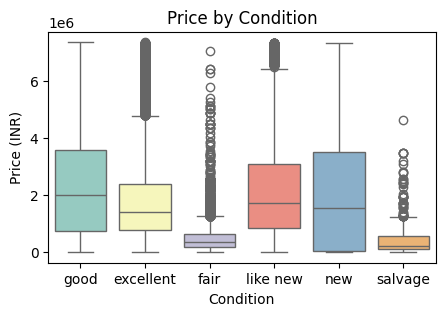

In [26]:
# Boxplot is used
plt.figure(figsize=(5, 3))
sns.boxplot(data=data, x='condition', y='price', palette='Set3',hue='condition')
plt.title("Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Price (INR)")
plt.show()

Hypothesis 7: Price by Car Type.

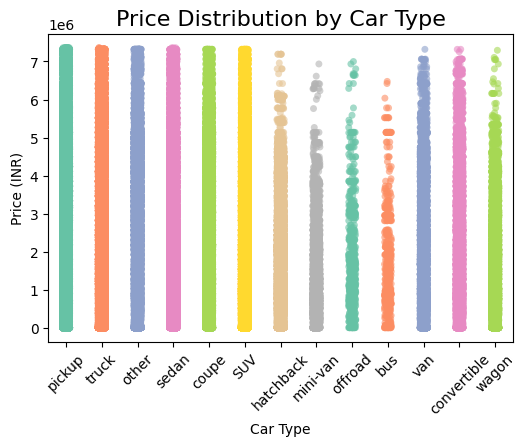

In [27]:
#Strip plot is used
plt.figure(figsize=(6, 4))
sns.stripplot(data=data, x='type', y='price', jitter=True, alpha=0.6, palette='Set2',hue='type')
plt.title("Price Distribution by Car Type", fontsize=16)
plt.xlabel("Car Type")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)
plt.show()

Hypothesis 8 : Trend during months.

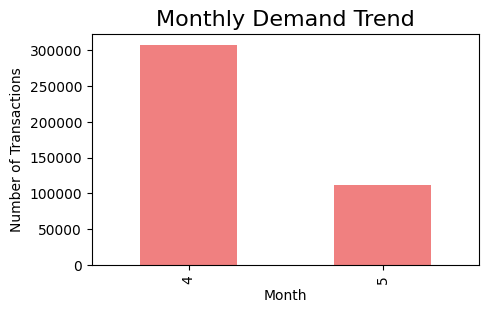

In [28]:
#Extract posting_month from the posting_date
data['posting_month'] = data['posting_date'].dt.month
#group by posting_month
monthly_transactions = data.groupby('posting_month')['id'].count()
#Bar plot is used
plt.figure(figsize=(5, 3))
monthly_transactions.plot(kind='bar', color='lightcoral')
plt.title("Monthly Demand Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

Hypothesis 9 : Price by year of manufacture ( the latest manufacture year the higher the price).

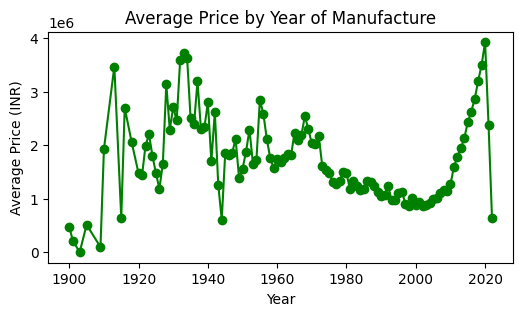

In [29]:
# Group by year of manufacture
yearly_prices = data.groupby('year')['price'].mean()

# Line plot is used
plt.figure(figsize=(6, 3))
yearly_prices.plot(kind='line', marker='o', color='green')
plt.title("Average Price by Year of Manufacture")
plt.xlabel("Year")
plt.ylabel("Average Price (INR)")
plt.show()

Hypothesis 10 : Price by Transmission Type.

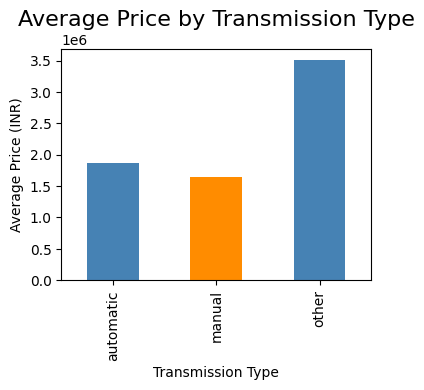

In [30]:
# Group by transmission and calculate average price
transmission_prices = data.groupby('transmission')['price'].mean()

# Stacked bar chart is used
plt.figure(figsize=(4, 3))
transmission_prices.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title("Average Price by Transmission Type", fontsize=16)
plt.xlabel("Transmission Type")
plt.ylabel("Average Price (INR)")
plt.show()